# Seq vs OMP vs FF - 3×3 Composites

This notebook compares **seq**, **omp**, and **ff** for **compute-focused metrics** by default:

- **Total time (compute-only)**: `reading_and_sorting_ms`  
  _(Can include the write time by uncommenting one line in Cell 1.)_
- **Speedup** (vs sequential @ threads = 1)
- **Efficiency** = speedup / threads

For each metric, we render **9 panels** for the manual pairs:
- records = [1_000_000, 10_000_000, 100_000_000]
- payload_max = [8, 32, 128]

Panels are stitched into a **single 3×3 image** and shown inline.

In [1]:
from pathlib import Path
import glob
import pandas as pd
import numpy as np
from itertools import product

# --- Paths (adjust CSV_GLOB if needed) ---
CSV_GLOB = "../results/*.csv"
CSV_GLOB_FALLBACK = "*.csv"
OUT_DIR = Path("plots_seq_omp_ff")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Manual 3×3 grid of (records, payload_max) ---
RECORDS = [1_000_000, 10_000_000, 100_000_000]
PAYLOAD_MAX = [8, 32, 128]
TOP_PAIRS = list(product(RECORDS, PAYLOAD_MAX))  # fills row-wise: 9 panels

def infer_impl_from_name(path: str) -> str:
    name = Path(path).name.lower()
    if "mpi" in name: return "mpi"
    if "fastflow" in name or "ff" in name: return "ff"
    if "openmp" in name or "omp" in name: return "omp"
    if "seq" in name or "sequential" in name: return "seq"
    return "unknown"

# --- Load all CSVs ---
csvs = glob.glob(CSV_GLOB, recursive=True) or glob.glob(CSV_GLOB_FALLBACK, recursive=False)
if not csvs:
    raise SystemExit("No CSV files found. Set CSV_GLOB and re-run.")

frames = []
for p in csvs:
    try:
        df = pd.read_csv(p)
    except Exception as e:
        print(f"Skipping {p}: {e}")
        continue
    if "impl" not in df.columns:
        df["impl"] = infer_impl_from_name(p)
    df["source_csv"] = p
    frames.append(df)

data_raw = pd.concat(frames, ignore_index=True)

# --- Focus on non-MPI only ---
data = data_raw[data_raw["impl"].isin(["seq","omp","ff"])].copy()

# --- Ensure required columns ---
required = ["reading_and_sorting_ms","writing_ms","threads","records","payload_max","sorted","impl"]
missing = [c for c in required if c not in data.columns]
if missing:
    raise SystemExit(f"Missing required columns: {missing}")

# --- Coerce numerics ---
for c in ["reading_and_sorting_ms","writing_ms","threads","records","payload_max","sorted"]:
    data[c] = pd.to_numeric(data[c], errors="coerce")

# --- Define total time ---
# Default: COMPUTE-ONLY metric. Uncomment the "+ writing_ms" to include write time as well.
data["total_ms"] = data["reading_and_sorting_ms"]  # + data["writing_ms"]  # <-- uncomment to include write time

# --- Debug: show unsorted rows BEFORE filtering ---
total_rows = len(data)
not_sorted = data[data["sorted"] != 1].copy()
print(f"Loaded rows (non-MPI): {total_rows} - rows with sorted != 1: {len(not_sorted)}")
if len(not_sorted) > 0:
    cols = ["impl","threads","records","payload_max","cutoff","total_ms","sorted","source_csv"]
    print("\nSample rows where sorted != 1:")
    display(not_sorted[cols].head(20))

# --- Keep only correct runs ---
data = data[data["sorted"] == 1].copy()
print("Kept rows (sorted==1):", len(data))


Loaded rows (non-MPI): 231 - rows with sorted != 1: 0
Kept rows (sorted==1): 231


## Unified plotting helpers

We keep a **single** renderer that can draw a panel for:
- `"time"` = median `total_ms`
- `"speedup"` vs sequential @ threads=1
- `"efficiency"` = speedup / threads

Then a **composite builder** assembles the 3×3 mosaic for any metric.


In [2]:
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

# Aggregate duplicates (trials/cutoffs) into one point per (impl, threads) via median
def aggregate_time(df):
    return (df.groupby(["impl","threads"], as_index=False)
              .agg(total_ms=("total_ms","median")))

def compute_curves(df_pair, metric: str):
    """
    Returns {impl: (threads_array, y_array)} for metric in {"time","speedup","efficiency"}.
    Assumes df_pair is already filtered to one (records, payload_max).
    """
    out = {}
    agg = aggregate_time(df_pair)

    if metric == "time":
        for impl in ["seq","omp","ff"]:
            dfi = agg[agg["impl"]==impl].sort_values("threads")
            if len(dfi):
                out[impl] = (dfi["threads"].to_numpy(), dfi["total_ms"].to_numpy())
        return out

    # Baseline for speedup/efficiency: sequential @ threads==1 (median)
    base = df_pair[(df_pair["impl"]=="seq") & (df_pair["threads"]==1)]
    if base.empty:
        return out
    Tref = base["total_ms"].median()

    agg = agg.copy()
    agg["speedup"] = Tref / agg["total_ms"]

    if metric == "speedup":
        for impl in ["seq","omp","ff"]:
            dfi = agg[agg["impl"]==impl].sort_values("threads")
            if len(dfi):
                out[impl] = (dfi["threads"].to_numpy(), dfi["speedup"].to_numpy())
        return out

    if metric == "efficiency":
        agg["efficiency"] = agg["speedup"] / agg["threads"]
        for impl in ["seq","omp","ff"]:
            dfi = agg[agg["impl"]==impl].sort_values("threads")
            if len(dfi):
                out[impl] = (dfi["threads"].to_numpy(), dfi["efficiency"].to_numpy())
        return out

    raise ValueError(f"Unknown metric: {metric}")

def make_panel(df_pair, rec, pay, metric: str, out_path: Path):
    """
    Render a mini-panel for a fixed (records, payload_max) & metric.
    - One figure per chart, no seaborn, no explicit colors.
    - Speedup plots: no ideal line (requested).
    """
    curves = compute_curves(df_pair, metric)
    plt.figure(figsize=(6,4))
    any_curve = False
    for impl in ["seq","omp","ff"]:
        if impl in curves:
            x, y = curves[impl]
            any_curve = True
            plt.plot(x, y, marker="o", label=impl.upper())
    plt.xlabel("Threads")
    if metric == "time":
        plt.ylabel("Total time (ms)")
    elif metric == "speedup":
        plt.ylabel("Speedup (vs seq@1)")
    else:
        plt.ylabel("Efficiency (S/p)")
    plt.title(f"N={rec}, payload_max={pay}")
    plt.grid(True)
    if any_curve:
        plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, bbox_inches="tight")
    plt.close()

def build_composite(metric: str, out_name: str):
    """
    Build the 3×3 mosaic for the provided metric and return the image path.
    """
    panel_paths = []
    for idx, (rec, pay) in enumerate(TOP_PAIRS):
        dfp = data[(data["records"]==rec) & (data["payload_max"]==pay)].copy()
        panel_path = OUT_DIR / f"{metric}_panel_{idx}_N{int(rec)}_K{int(pay)}.png"
        if dfp.empty:
            # placeholder if no data for that pair
            plt.figure(figsize=(6,4))
            plt.title(f"N={rec}, payload_max={pay}\n(no data)")
            plt.axis("off")
            plt.savefig(panel_path, bbox_inches="tight")
            plt.close()
        else:
            make_panel(dfp, rec, pay, metric, panel_path)
        panel_paths.append(panel_path)

    # Stitch 3×3
    imgs = [Image.open(p) for p in panel_paths]
    w = max(im.size[0] for im in imgs)
    h = max(im.size[1] for im in imgs)
    norm = []
    for im in imgs:
        if im.size != (w,h):
            im = im.resize((w,h))
        norm.append(im)

    cols, rows = 3, 3
    mosaic = Image.new("RGB", (cols*w, rows*h), "white")
    for i, im in enumerate(norm):
        r, c = divmod(i, cols)
        mosaic.paste(im, (c*w, r*h))
    out_path = OUT_DIR / out_name
    mosaic.save(out_path)
    return out_path


## Build & display the 3×3 composites
We generate **time**, **speedup**, and **efficiency** mosaics and display them inline.


Total time (compute-only) - 3×3 composite


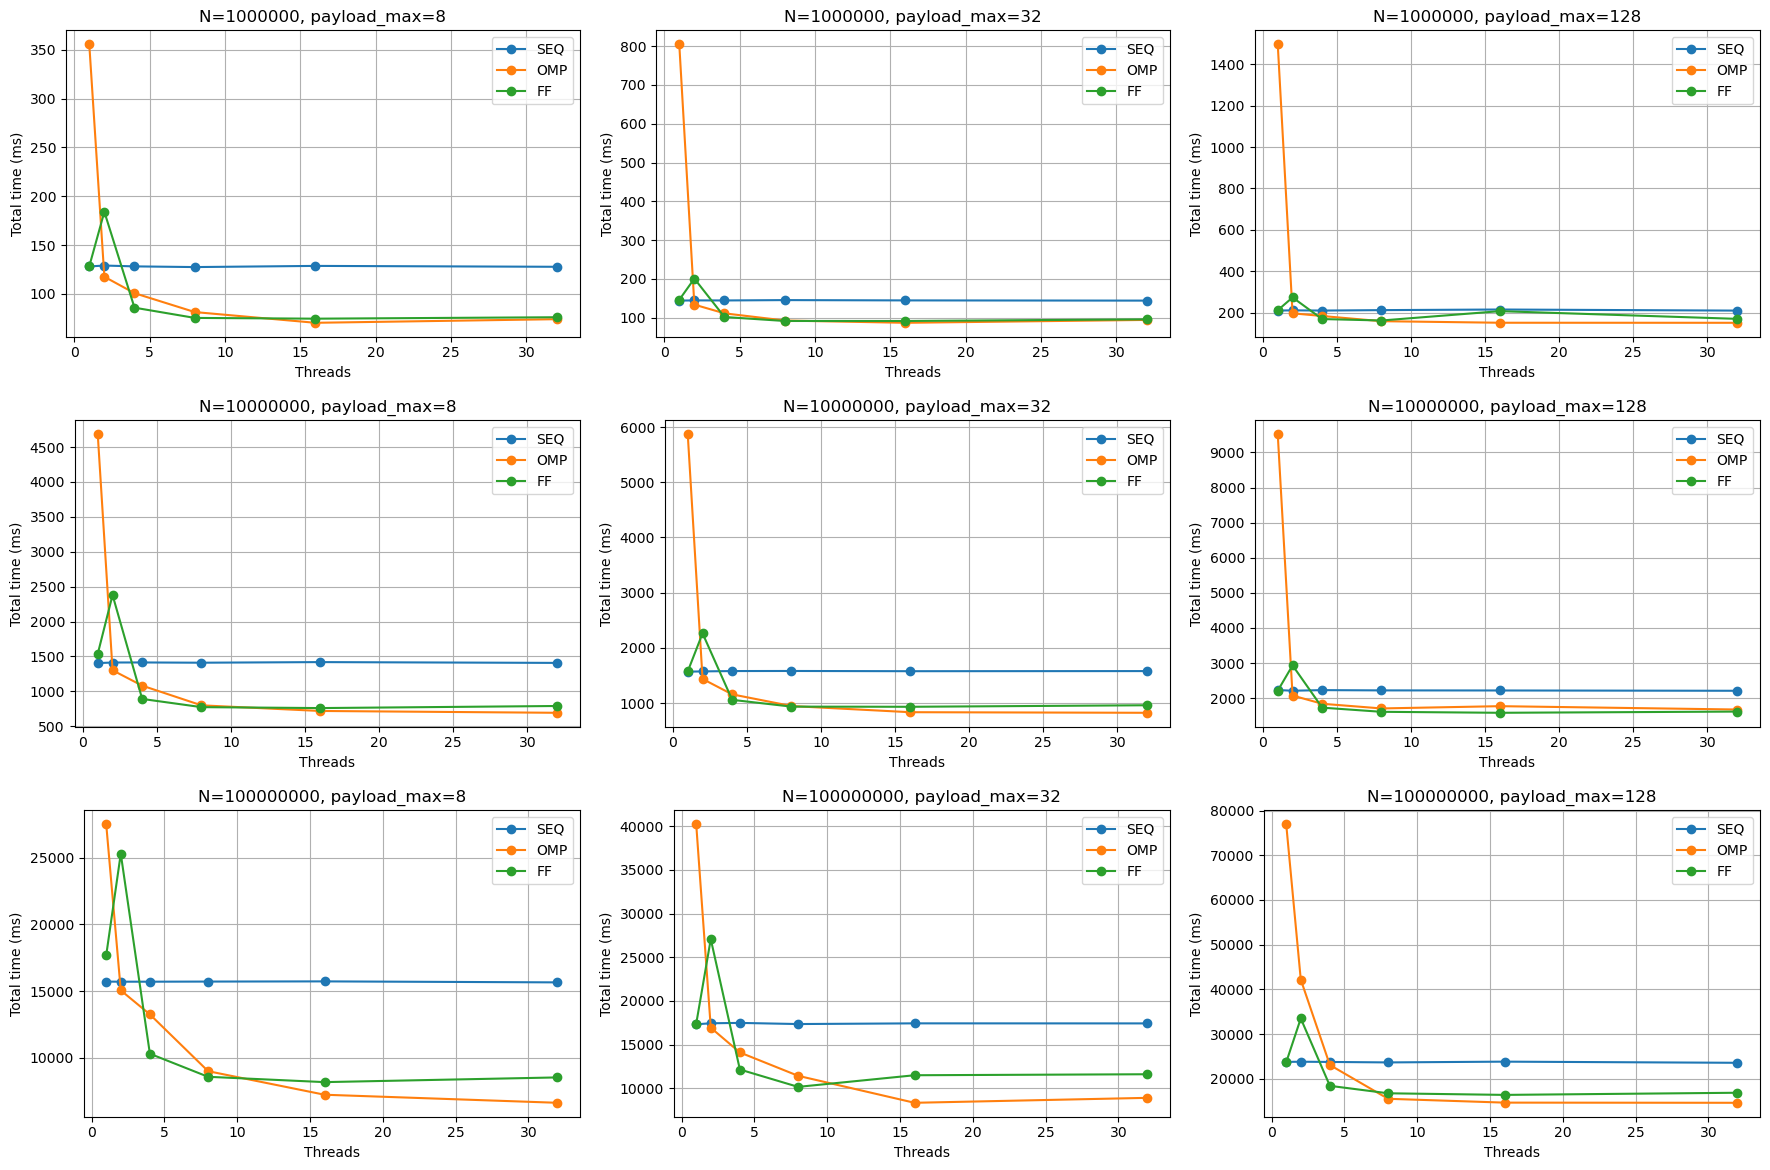

Speedup (vs seq@1) - 3×3 composite


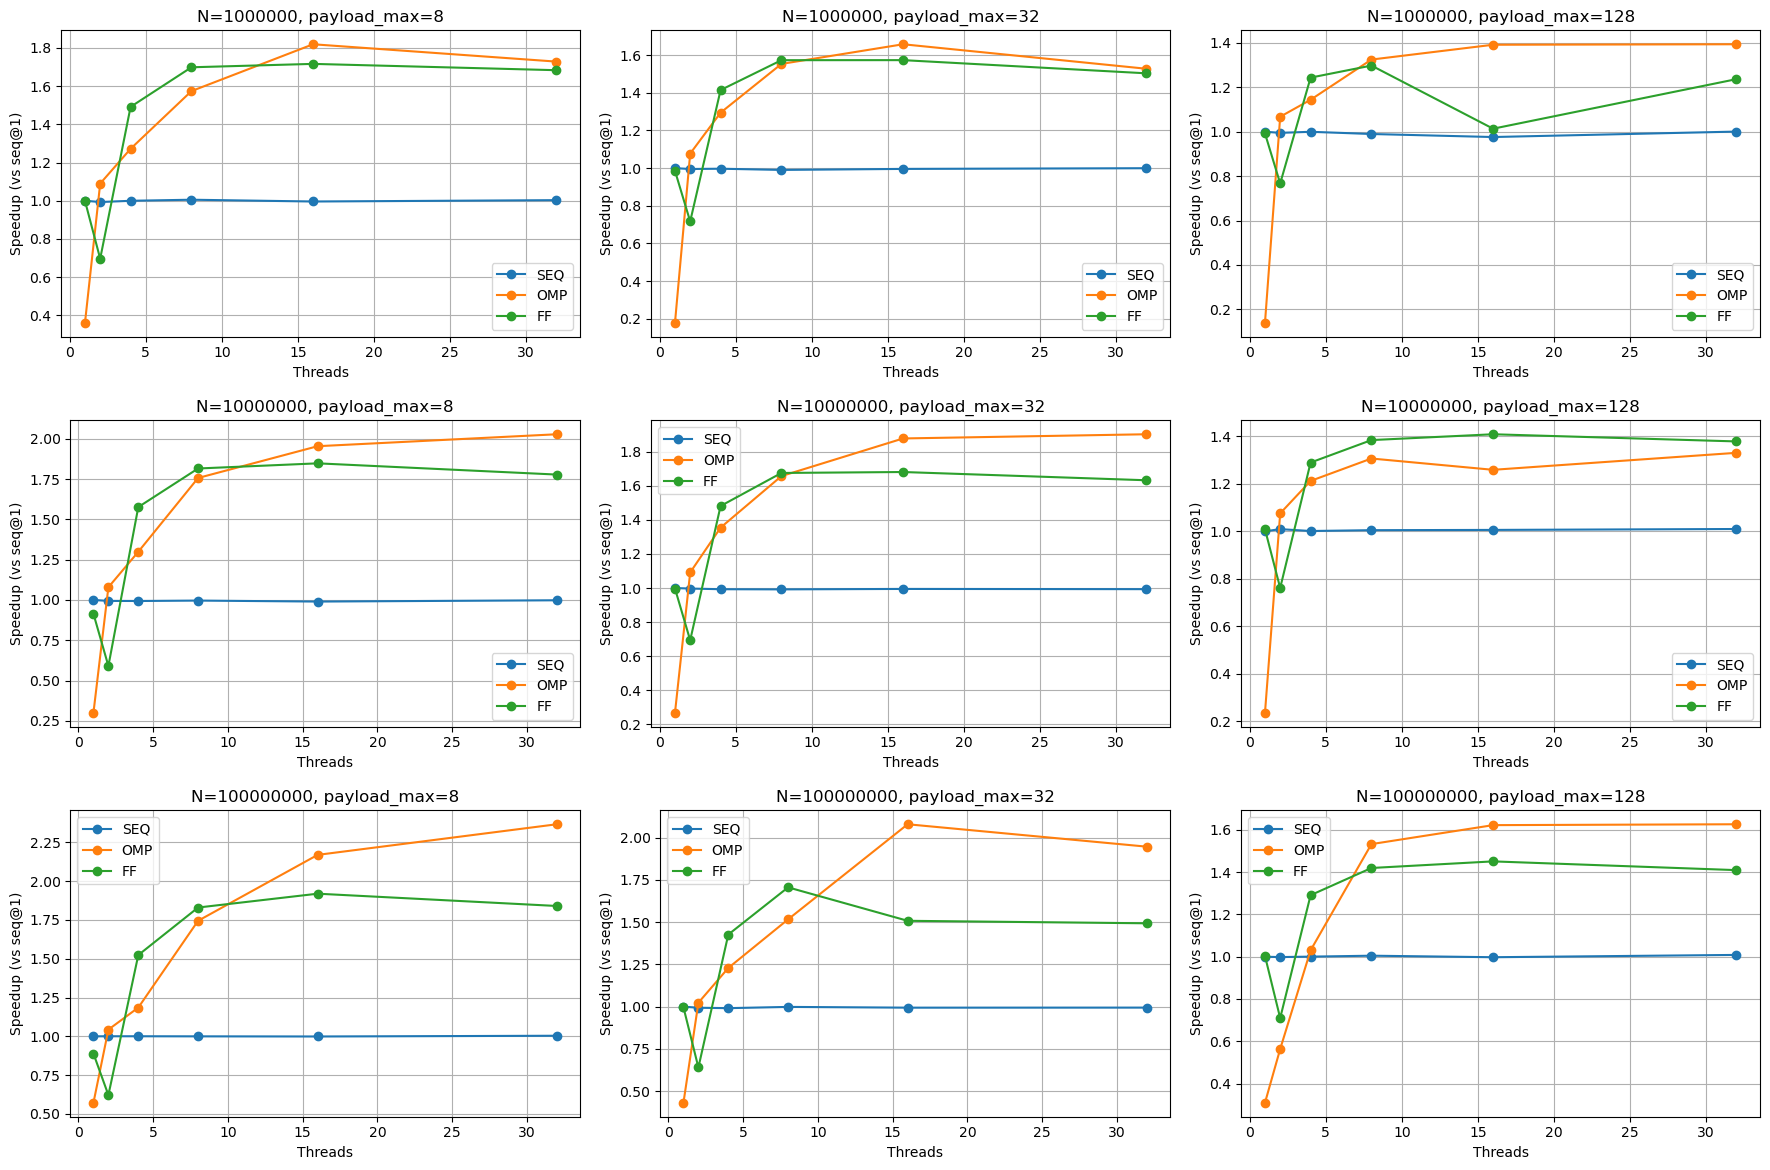

Efficiency (S/p) - 3×3 composite


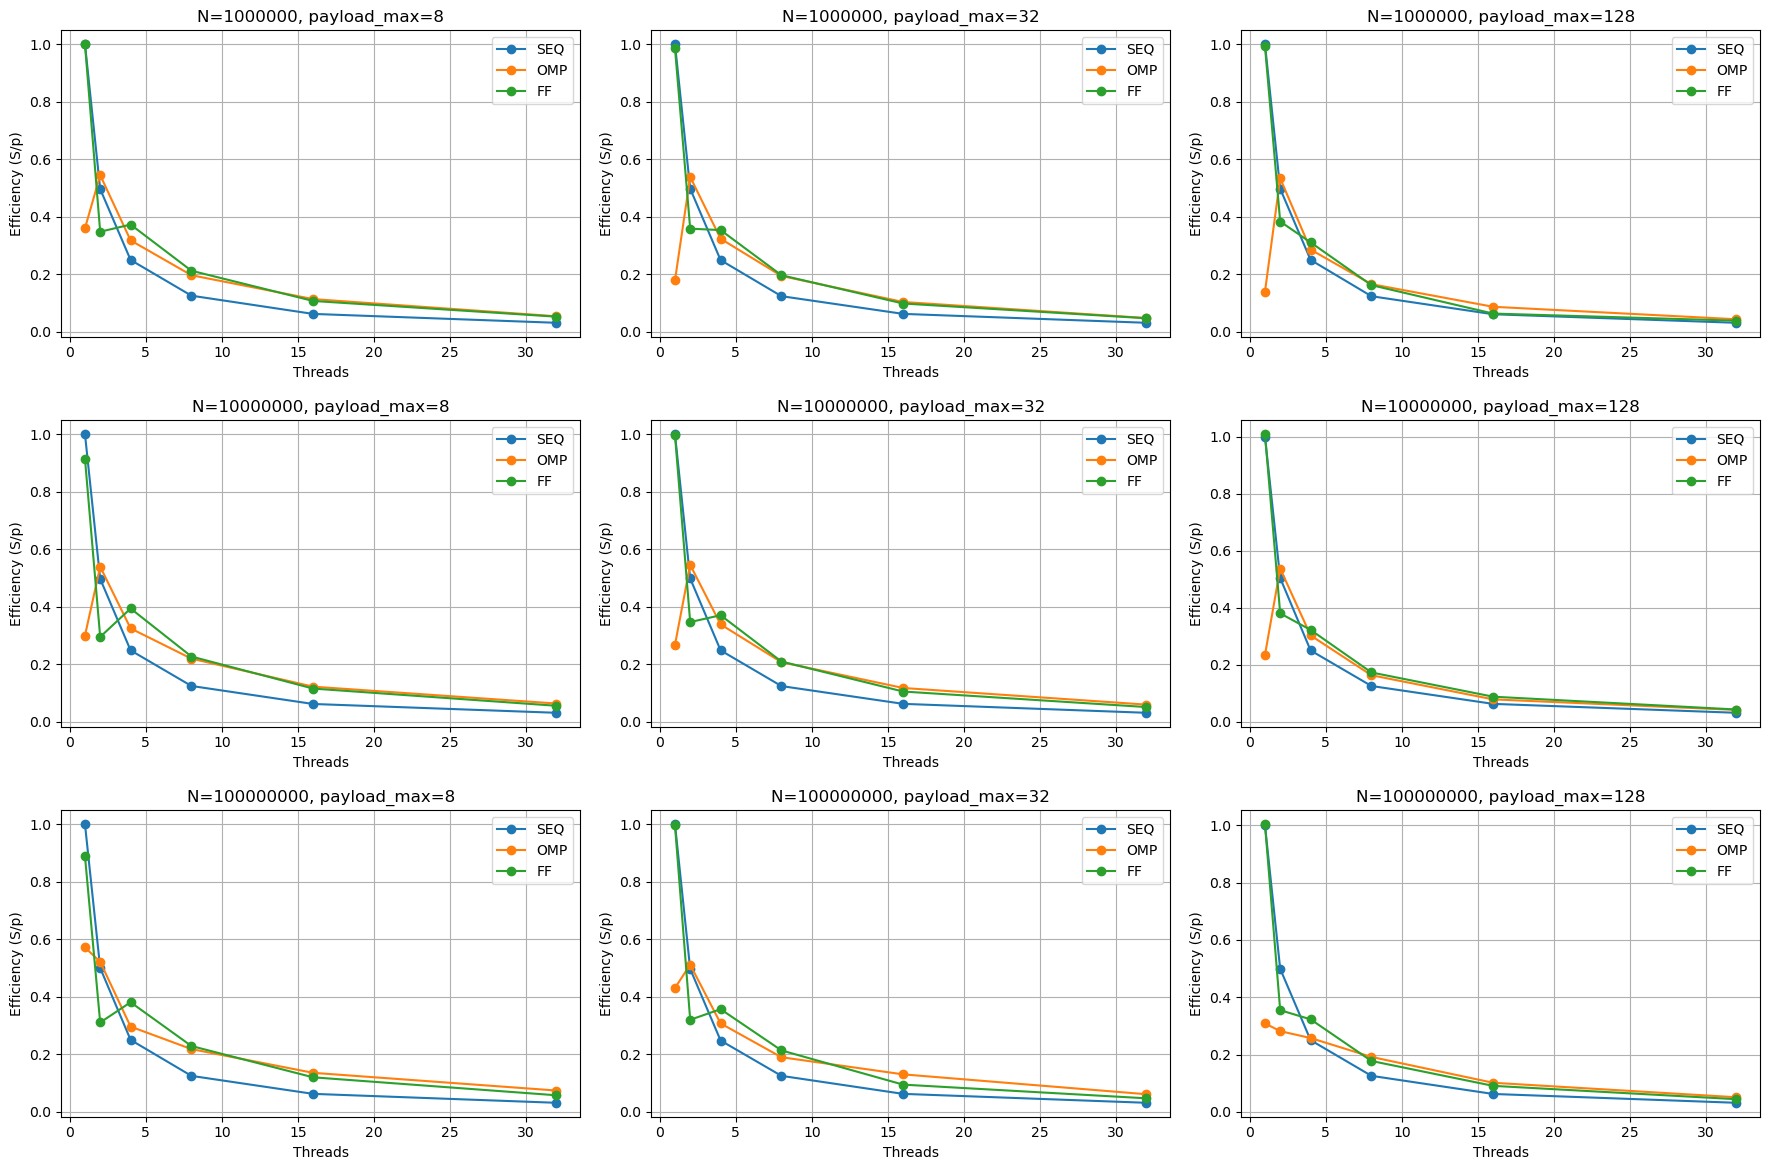

In [3]:
from IPython.display import display
from PIL import Image

# Build composites
time_path  = build_composite(metric="time",       out_name="composite_time_3x3.png")
speed_path = build_composite(metric="speedup",    out_name="composite_speedup_3x3.png")
eff_path   = build_composite(metric="efficiency", out_name="composite_efficiency_3x3.png")

# Show inline
print("Total time (compute-only) - 3×3 composite")
display(Image.open(time_path))

print("Speedup (vs seq@1) - 3×3 composite")
display(Image.open(speed_path))

print("Efficiency (S/p) - 3×3 composite")
display(Image.open(eff_path))


## Quick look: render a **single** panel inline
Set `N_CHOICE`, `K_CHOICE`, and `METRIC_CHOICE ∈ {"time","speedup","efficiency"}` to preview one panel without searching the folder.


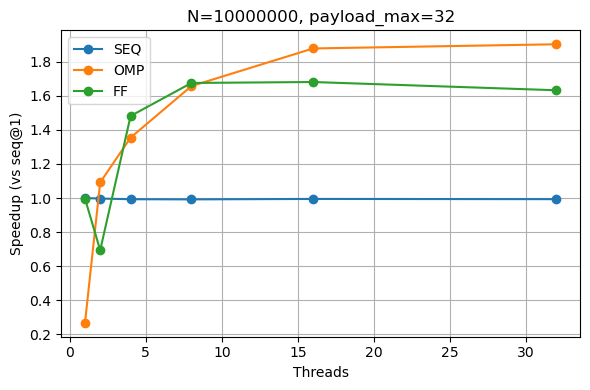

In [4]:
N_CHOICE = 10_000_000
K_CHOICE = 32
METRIC_CHOICE = "speedup"   # "time" | "speedup" | "efficiency"

from IPython.display import display
from PIL import Image

df_single = data[(data["records"]==N_CHOICE) & (data["payload_max"]==K_CHOICE)].copy()
single_out = OUT_DIR / f"single_{METRIC_CHOICE}_N{int(N_CHOICE)}_K{int(K_CHOICE)}.png"
if df_single.empty:
    print(f"No data for N={N_CHOICE}, payload_max={K_CHOICE}")
else:
    make_panel(df_single, N_CHOICE, K_CHOICE, METRIC_CHOICE, single_out)
    display(Image.open(single_out))


## Weak scaling - setup (relative scaling)

We fix `payload_max = 32` and choose a base size $N_0 = 1{,}000{,}000$ at `threads = 1`.  
For each thread count $p \in \{1,2,4,8,16,32\}$ we pick the **exact** input size $n_p$ by solving

$$
n_p \,\log_2 n_p \;=\; p \,\bigl(N_0 \log_2 N_0\bigr),
$$

so that the **work per thread** stays constant:
$$
\frac{n_p \log_2 n_p}{p} \;=\; N_0 \log_2 N_0.
$$

We will print the exact `records = n_p` you must run for **each** $p$.  
Because we’re doing **relative weak speedup**, for every implementation (OMP and FF) you must measure **both**:
- $T_{\text{impl}}(1, n_p)$ : the implementation on **1 thread** at size $n_p$
- $T_{\text{impl}}(p, n_p)$ : the same implementation on **p threads** at size $n_p$

*(This is per-implementation; the sequential code is not used as a numerator here.)*


In [5]:
# --- Compute & print exact weak-scaling sizes n_p (no CSV) ---
import math

# --- Constants (plain assignments for clarity) ---
PAYLOAD_FIX = 32
P_LIST = [1, 2, 4, 8, 16, 32]
N0 = 1_000_000  # base size used for the per-impl baseline

W0 = N0 * math.log2(N0)

def solve_n_for_target_work(w_target: float) -> float:
    if w_target <= 0:
        return 0.0
    n = max(2.0, w_target / max(1.0, math.log2(w_target + 2.0)))  # initial guess
    for _ in range(50):
        f = n * math.log2(n) - w_target
        if abs(f) <= 1e-12 * max(1.0, w_target): break
        df = math.log2(n) + 1.0 / math.log(2.0)
        n -= f / df
        if n < 2.0: n = 2.0
    return n

exact_records = {}
print(f"Weak-scaling targets (payload_max={PAYLOAD_FIX}, base N0={N0})")
print(f"Baseline W0 = N0*log2(N0) = {W0:,.2f}")
print(f"{'p':>3} {'records_to_run (n_p)':>20} {'(n log2 n)/p':>18} {'ratio_to_W0':>14} {'error_ppm':>12}")
for p in P_LIST:
    n_float = solve_n_for_target_work(W0 * p)
    n_int = int(round(n_float))
    per_thread = (n_int * math.log2(n_int)) / p
    ratio = per_thread / W0
    err_ppm = 0.0 if W0 == 0 else (per_thread - W0) / W0 * 1e6
    exact_records[p] = n_int
    print(f"{p:3d} {n_int:20,d} {per_thread:18,.2f} {ratio:14.8f} {err_ppm:12.2f}")

print("\nCopy for your run scripts (per p):")
print("P_LIST        =", P_LIST)
print("RECORDS_PER_P =", [exact_records[p] for p in P_LIST])


Weak-scaling targets (payload_max=32, base N0=1000000)
Baseline W0 = N0*log2(N0) = 19,931,568.57
  p records_to_run (n_p)       (n log2 n)/p    ratio_to_W0    error_ppm
  1            1,000,000      19,931,568.57     1.00000000         0.00
  2            1,910,480      19,931,563.78     0.99999976        -0.24
  4            3,656,807      19,931,566.48     0.99999990        -0.10
  8            7,011,582      19,931,568.72     1.00000001         0.01
 16           13,465,692      19,931,568.06     0.99999997        -0.03
 32           25,899,431      19,931,568.43     0.99999999        -0.01

Copy for your run scripts (per p):
P_LIST        = [1, 2, 4, 8, 16, 32]
RECORDS_PER_P = [1000000, 1910480, 3656807, 7011582, 13465692, 25899431]


## Weak scaling - **relative** speedup & efficiency (plots in one row)

For each implementation (**OMP**, **FF**), we compute:

- **Relative weak speedup** (per-implementation):  
  $$S_{\mathrm{rel}}(p) = \frac{T_{\text{impl}}(1, N_0)}{T_{\text{impl}}(p, n_p)}$$

- **Relative efficiency**:  
  $$E_{\mathrm{rel}}(p) = \frac{S_{\mathrm{rel}}(p)}{p}$$

We also show the **parallel time** $T_{\text{impl}}(p, n_p)$ vs threads.  
All metrics use your current `total_ms` definition (compute-only by default; include I/O if you previously toggled `+ writing_ms`).  
Only **exact tuples** `(impl, threads=p, records=n_p, payload_max=32, sorted=1)` are used; missing ones are listed so you can run them.


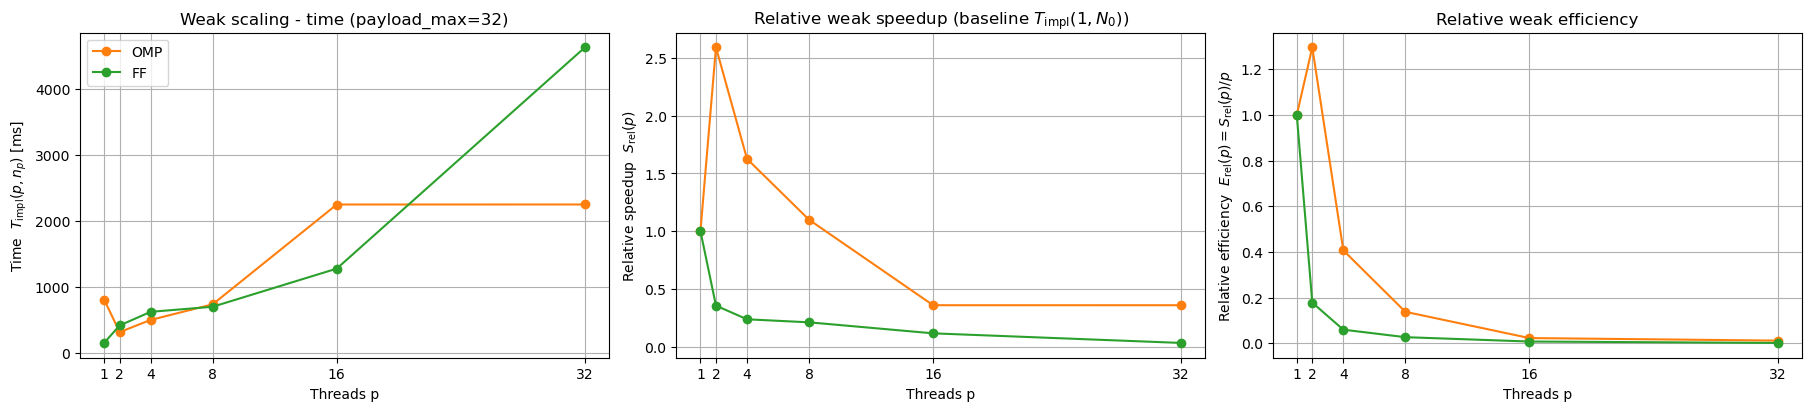

In [6]:
# === Relative weak speedup & efficiency with per-impl fixed baseline T_impl(1, N0) ===
# Uses:
# - exact_records (dict p -> n_p) from the previous cell
# - PAYLOAD_FIX, P_LIST, N0
# - data   (filtered to sorted==1) with column 'total_ms' already defined

import pandas as pd
import matplotlib.pyplot as plt

# Build relative metrics
rows_rel = []
missing = []

for impl in ["omp", "ff"]:
    # Per-implementation fixed baseline at (threads=1, records=N0)
    base_df = data[
        (data["impl"] == impl) &
        (data["threads"] == 1) &
        (data["payload_max"] == PAYLOAD_FIX) &
        (data["records"] == N0)
    ]
    if base_df.empty:
        missing.append((impl, 1, N0, "baseline_missing"))
        # Skip this implementation entirely if its baseline is missing
        continue
    T1_fixed = base_df["total_ms"].median()

    # Now compute S_rel(p) = T_impl(1, N0) / T_impl(p, n_p) and E_rel = S_rel / p
    for p in P_LIST:
        n_p = exact_records.get(p)
        if n_p is None:
            missing.append((impl, p, None, "n_p_missing"))
            continue

        dfp = data[
            (data["impl"] == impl) &
            (data["threads"] == p) &
            (data["payload_max"] == PAYLOAD_FIX) &
            (data["records"] == n_p)
        ]
        if dfp.empty:
            missing.append((impl, p, n_p, "tuple_missing"))
            continue

        Tp = dfp["total_ms"].median()
        S_rel = T1_fixed / Tp
        E_rel = S_rel / p

        rows_rel.append({
            "impl": impl,
            "threads": p,
            "records": n_p,
            "T_impl_p_ms": Tp,
            "S_rel": S_rel,
            "E_rel": E_rel,
        })

weak_rel_df = pd.DataFrame(rows_rel).sort_values(["impl", "threads"]).reset_index(drop=True)

# Report missing tuples/baselines so you know what to run
if missing:
    print("Missing items for relative weak speedup (impl, threads, records, reason):")
    for t in missing:
        print("  ", t)

# --- Three plots in one row: Time, Relative Speedup, Relative Efficiency ---
fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)

COLORS = {"omp": "tab:orange", "ff": "tab:green"}

# 1) Parallel time vs threads: T_impl(p, n_p)
ax = axes[0]
for impl in ["omp", "ff"]:
    dfi = weak_rel_df[weak_rel_df["impl"] == impl].sort_values("threads")
    if dfi.empty:
        continue
    ax.plot(dfi["threads"], dfi["T_impl_p_ms"], marker="o", label=impl.upper(), color=COLORS.get(impl))
ax.set_xlabel("Threads p")
ax.set_ylabel(r"Time  $T_{\mathrm{impl}}(p, n_p)$ [ms]")
ax.set_title(f"Weak scaling - time (payload_max={PAYLOAD_FIX})")
ax.set_xticks(P_LIST)
ax.grid(True)
ax.legend()

# 2) Relative weak speedup: S_rel(p) = T_impl(1, N0) / T_impl(p, n_p)
ax = axes[1]
for impl in ["omp", "ff"]:
    dfi = weak_rel_df[weak_rel_df["impl"] == impl].sort_values("threads")
    if dfi.empty:
        continue
    ax.plot(dfi["threads"], dfi["S_rel"], marker="o", label=impl.upper(), color=COLORS.get(impl))
ax.set_xlabel("Threads p")
ax.set_ylabel(r"Relative speedup  $S_{\mathrm{rel}}(p)$")
ax.set_title(r"Relative weak speedup (baseline $T_{\mathrm{impl}}(1, N_0)$)")
ax.set_xticks(P_LIST)
ax.grid(True)

# 3) Relative efficiency: E_rel(p) = S_rel(p) / p
ax = axes[2]
for impl in ["omp", "ff"]:
    dfi = weak_rel_df[weak_rel_df["impl"] == impl].sort_values("threads")
    if dfi.empty:
        continue
    ax.plot(dfi["threads"], dfi["E_rel"], marker="o", label=impl.upper(), color=COLORS.get(impl))
ax.set_xlabel("Threads p")
ax.set_ylabel(r"Relative efficiency  $E_{\mathrm{rel}}(p)=S_{\mathrm{rel}}(p)/p$")
ax.set_title("Relative weak efficiency")
ax.set_xticks(P_LIST)
ax.grid(True)

plt.show()


## Strong scaling — **relative** speedup & efficiency (fixed problem size)

We fix the problem size at $N = N_0 = 100{,}000{,}000$ and `payload_max = 32`, and vary the thread count $p \in \{1,2,4,8,16,32\}$.  
For each implementation (**OMP**, **FF**) we compute:

- **Relative strong speedup** (per-implementation):  
  $$S_{\mathrm{rel}}(p) \;=\; \frac{T_{\text{impl}}(1, N_0)}{T_{\text{impl}}(p, N_0)}$$

- **Relative strong efficiency**:  
  $$E_{\mathrm{rel}}(p) \;=\; \frac{S_{\mathrm{rel}}(p)}{p}$$

We also plot the **parallel time** $T_{\text{impl}}(p, N_0)$ vs threads.  
All metrics use your current `total_ms` definition (compute-only by default; include I/O if you previously toggled `+ writing_ms`).  
Only **exact tuples** `(impl, threads=p, records=N_0, payload_max=32, sorted=1)` are used; missing ones are listed so you can run them.


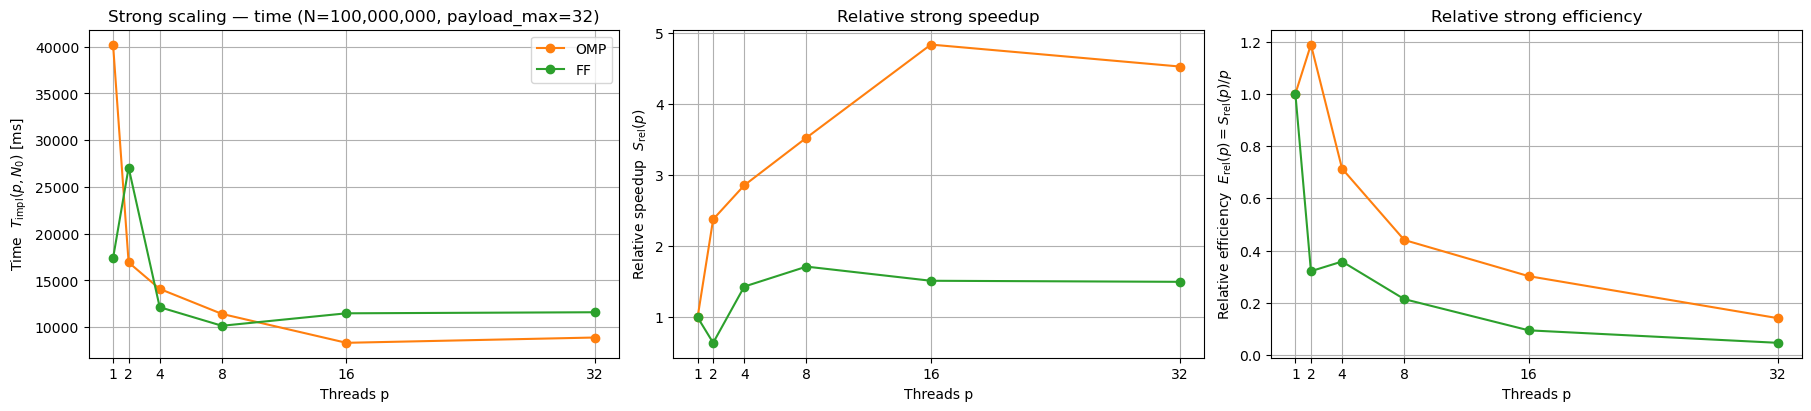

In [8]:
# === Strong scaling (relative) for OMP & FF, three plots side-by-side ===
import pandas as pd
import matplotlib.pyplot as plt

# Constants
PAYLOAD_FIX = 32
P_LIST = [1, 2, 4, 8, 16, 32]
N0 = 100_000_000   # fixed problem size for strong scaling

# Colors (OMP=orange, FF=green)
COLORS = {"omp": "tab:orange", "ff": "tab:green"}

# Ensure 'data' exists (filtered to sorted==1) and has 'total_ms'
if 'data' not in globals():
    raise RuntimeError("Expected a 'data' DataFrame in scope. Run the load/filter cell first.")

rows = []
missing = []

for impl in ["omp", "ff"]:
    # Baseline: T_impl(1, N0)
    base = data[(data["impl"]==impl) &
                (data["threads"]==1) &
                (data["payload_max"]==PAYLOAD_FIX) &
                (data["records"]==N0)]
    if base.empty:
        missing.append((impl, 1, N0, "baseline_missing"))
        continue
    T1 = base["total_ms"].median()

    # Points for each p
    for p in P_LIST:
        dfp = data[(data["impl"]==impl) &
                   (data["threads"]==p) &
                   (data["payload_max"]==PAYLOAD_FIX) &
                   (data["records"]==N0)]
        if dfp.empty:
            missing.append((impl, p, N0, "tuple_missing"))
            continue
        Tp = dfp["total_ms"].median()
        S_rel = T1 / Tp
        E_rel = S_rel / p

        rows.append({
            "impl": impl,
            "threads": p,
            "T_impl_p_ms": Tp,
            "S_rel": S_rel,
            "E_rel": E_rel
        })

strong_rel_df = pd.DataFrame(rows).sort_values(["impl","threads"]).reset_index(drop=True)

if missing:
    print("Missing tuples for relative strong scaling (impl, threads, records, reason):")
    for t in missing:
        print("  ", t)

# --- Three subplots in one row: Time, Relative Speedup, Relative Efficiency ---
fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)

# 1) Time vs threads
ax = axes[0]
for impl in ["omp", "ff"]:
    dfi = strong_rel_df[strong_rel_df["impl"]==impl].sort_values("threads")
    if dfi.empty: continue
    ax.plot(dfi["threads"], dfi["T_impl_p_ms"], marker="o", label=impl.upper(), color=COLORS.get(impl))
ax.set_xlabel("Threads p"); ax.set_ylabel(r"Time  $T_{\mathrm{impl}}(p, N_0)$ [ms]")
ax.set_title(f"Strong scaling — time (N={N0:,}, payload_max={PAYLOAD_FIX})")
ax.set_xticks(P_LIST); ax.grid(True); ax.legend()

# 2) Relative strong speedup
ax = axes[1]
for impl in ["omp", "ff"]:
    dfi = strong_rel_df[strong_rel_df["impl"]==impl].sort_values("threads")
    if dfi.empty: continue
    ax.plot(dfi["threads"], dfi["S_rel"], marker="o", label=impl.upper(), color=COLORS.get(impl))
ax.set_xlabel("Threads p"); ax.set_ylabel(r"Relative speedup  $S_{\mathrm{rel}}(p)$")
ax.set_title("Relative strong speedup")
ax.set_xticks(P_LIST); ax.grid(True)

# 3) Relative strong efficiency
ax = axes[2]
for impl in ["omp", "ff"]:
    dfi = strong_rel_df[strong_rel_df["impl"]==impl].sort_values("threads")
    if dfi.empty: continue
    ax.plot(dfi["threads"], dfi["E_rel"], marker="o", label=impl.upper(), color=COLORS.get(impl))
ax.set_xlabel("Threads p"); ax.set_ylabel(r"Relative efficiency  $E_{\mathrm{rel}}(p)=S_{\mathrm{rel}}(p)/p$")
ax.set_title("Relative strong efficiency")
ax.set_xticks(P_LIST); ax.grid(True)

plt.show()


## MPI · Block 1 — Execution time vs number of nodes (N ∈ {1e6, 1e7, 1e8})

We fix `payload_max = 32` and plot **median total time** vs **number of nodes** for:

- $N \in \{1{,}000{,}000,\; 10{,}000{,}000,\; 100{,}000{,}000\}$
- lines = **threads per node** $\in \{1,2,4,8,16,32\}$

This shows how adding nodes impacts wall-clock time at fixed problem sizes while varying intra-node parallelism.


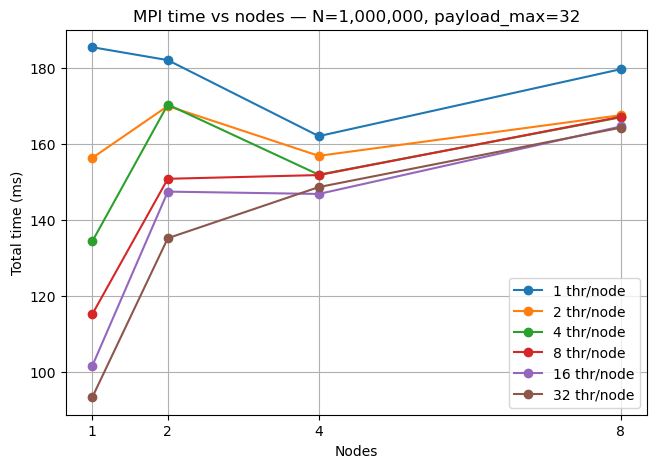

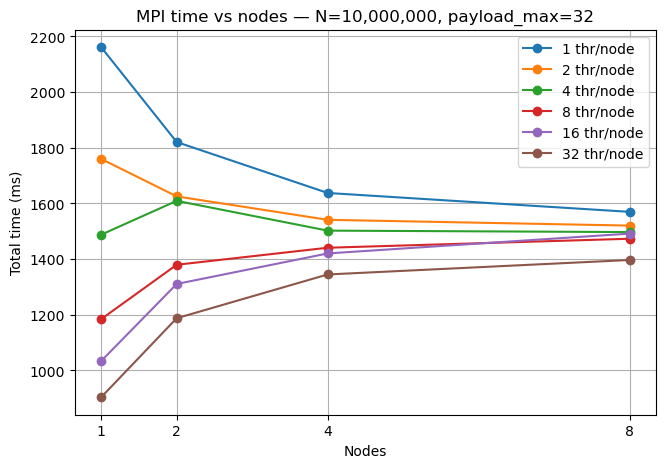

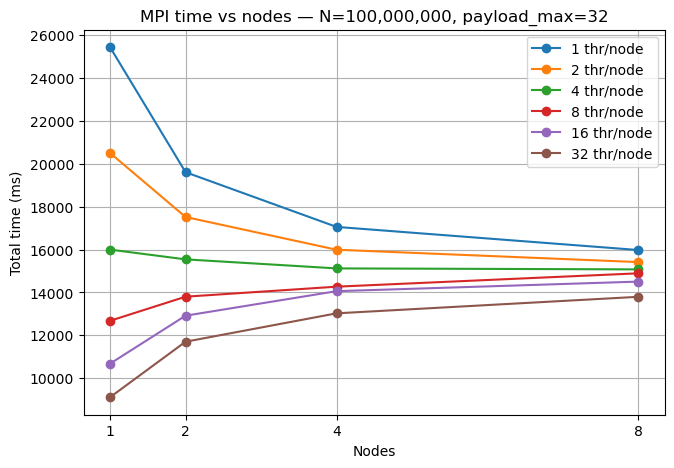

In [9]:
# --- MPI · Block 1: Time vs nodes, lines = threads-per-node, for N ∈ {1e6,1e7,1e8} ---
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Config ---
PAYLOAD_FIX = 32
N_LIST = [1_000_000, 10_000_000, 100_000_000]
THREADS_PER_NODE_LIST = [1, 2, 4, 8, 16, 32]
NODES_AXIS = [1, 2, 4, 8]

# --- Get MPI data (sorted==1), ensure columns ---
if 'data_raw' not in globals():
    raise RuntimeError("Expected 'data_raw' from the loader cell. Please run it first.")

mpi = data_raw.copy()
# compute 'total_ms' if not present
if "total_ms" not in mpi.columns:
    if {"reading_and_sorting_ms","writing_ms"}.issubset(mpi.columns):
        # Respect your current toggle: compute-only unless you previously added + writing_ms in your loader
        mpi["total_ms"] = mpi["reading_and_sorting_ms"]  # + mpi["writing_ms"]
    else:
        raise RuntimeError("MPI data missing timing columns needed to compute total_ms.")

# keep only mpi and correct runs
mpi = mpi[(mpi["impl"] == "mpi") & (mpi["sorted"] == 1)].copy()

# basic checks / coercions
need_cols = ["nodes","threads","records","payload_max","total_ms"]
missing = [c for c in need_cols if c not in mpi.columns]
if missing:
    # small attempt to infer 'nodes' from filename if absent; otherwise fail
    if "nodes" in missing and "source_csv" in mpi.columns:
        def infer_nodes(path):
            m = re.search(r"(?:nodes?|nnodes|np)[^\d]*(\d+)", str(path).lower())
            return int(m.group(1)) if m else np.nan
        mpi["nodes"] = mpi["source_csv"].map(infer_nodes).astype("Int64")
        if mpi["nodes"].isna().any():
            raise RuntimeError("Could not infer 'nodes' for all MPI rows. Please include a 'nodes' column in MPI CSVs.")
        missing.remove("nodes")
    if missing:
        raise RuntimeError(f"MPI data missing columns: {missing}")

for c in ["nodes","threads","records","payload_max","total_ms"]:
    mpi[c] = pd.to_numeric(mpi[c], errors="coerce")

# aggregate helper
def agg_time(df):
    return (df.groupby(["nodes","threads"], as_index=False)
              .agg(total_ms=("total_ms","median")))

COLORS_TPN = {1:"tab:blue",2:"tab:orange",4:"tab:green",8:"tab:red",16:"tab:purple",32:"tab:brown"}

# Make one plot per N
for N in N_LIST:
    dfN = mpi[(mpi["records"] == N) & (mpi["payload_max"] == PAYLOAD_FIX)].copy()
    if dfN.empty:
        print(f"(info) No MPI data for N={N:,}, payload_max={PAYLOAD_FIX}")
        continue
    ag = agg_time(dfN)

    plt.figure(figsize=(7.5,5))
    for tpn in THREADS_PER_NODE_LIST:
        dfl = ag[ag["threads"] == tpn].sort_values("nodes")
        if dfl.empty:
            continue
        xs = [n for n in NODES_AXIS if n in dfl["nodes"].values]
        if not xs:
            continue
        ys = [dfl[dfl["nodes"]==x]["total_ms"].values[0] for x in xs]
        plt.plot(xs, ys, marker="o", label=f"{tpn} thr/node", color=COLORS_TPN.get(tpn))

    plt.xticks(NODES_AXIS)
    plt.xlabel("Nodes")
    plt.ylabel("Total time (ms)")
    plt.title(f"MPI time vs nodes — N={N:,}, payload_max={PAYLOAD_FIX}")
    plt.grid(True)
    plt.legend()
    plt.show()


## MPI · Block 2 — **Absolute** speedup vs sequential (N = 1e8), plus efficiency & times

- Fix $N = 100{,}000{,}000$ and `payload_max = 32`.
- **Speedup** (absolute):  
  $$S_{\text{abs}}(\text{nodes}, t) = \frac{T_{\text{seq}}(1, N)}{T_{\text{mpi}}(\text{nodes}, t,\; N)}$$
- **Efficiency**:  
  $$E_{\text{abs}}(\text{nodes}) = \frac{S_{\text{abs}}(\text{nodes}, t)}{\text{nodes}}$$

x-axis = **nodes**; lines = **threads per node** $t \in \{1,2,4,8,16,32\}$.  
Left subplot shows the **times** with a **horizontal dotted line** at $T_{\text{seq}}(1, N)$.


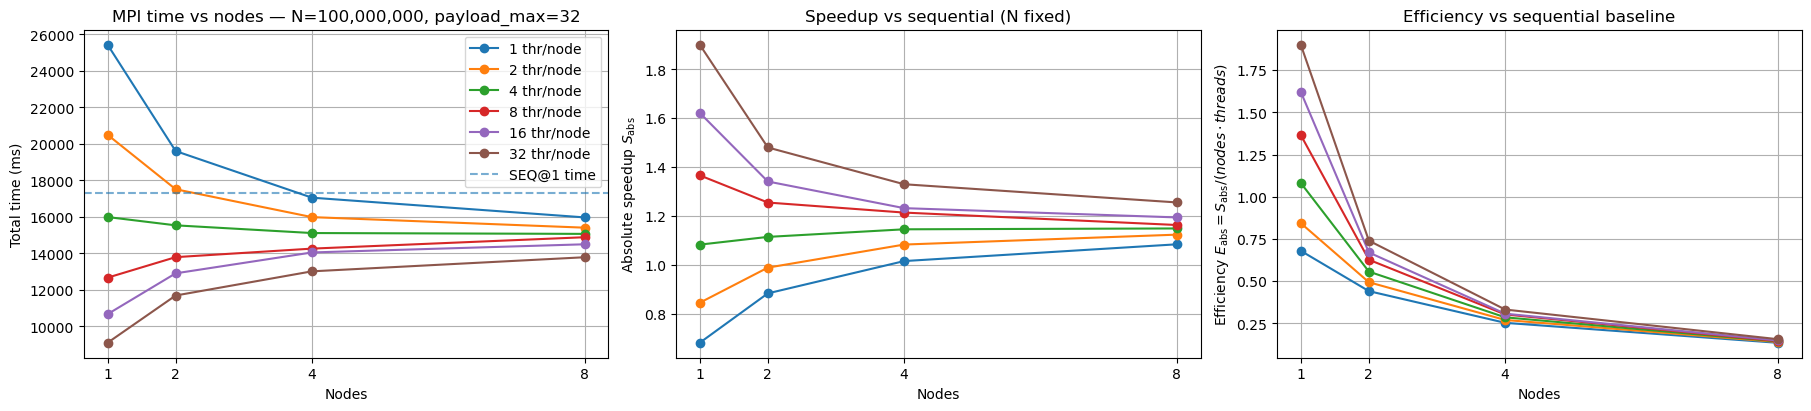

In [11]:
# --- MPI · Block 2: Absolute speedup & efficiency vs seq at N=1e8 (times + speedup + efficiency) ---
import pandas as pd
import matplotlib.pyplot as plt

PAYLOAD_FIX = 32
N = 100_000_000
THREADS_PER_NODE_LIST = [1, 2, 4, 8, 16, 32]
NODES_AXIS = [1, 2, 4, 8]
COLORS_TPN = {1:"tab:blue",2:"tab:orange",4:"tab:green",8:"tab:red",16:"tab:purple",32:"tab:brown"}

# Baseline sequential time at 1 thread, size N
df_seq = data_raw[(data_raw["impl"]=="seq") &
                  (data_raw["threads"]==1) &
                  (data_raw["payload_max"]==PAYLOAD_FIX) &
                  (data_raw["records"]==N) &
                  (data_raw["sorted"]==1)].copy()
if df_seq.empty:
    raise RuntimeError("Missing sequential baseline for N=1e8, payload_max=32 (impl=seq, threads=1).")
T_seq = (df_seq["reading_and_sorting_ms"]).median()  # matches 'compute-only' convention; add +writing_ms if you toggled

# MPI slice
mpiN = mpi[(mpi["records"]==N) & (mpi["payload_max"]==PAYLOAD_FIX)].copy()
if mpiN.empty:
    raise RuntimeError("No MPI rows for N=1e8, payload_max=32.")

# aggregate times
ag = (mpiN.groupby(["nodes","threads"], as_index=False)
           .agg(total_ms=("total_ms","median")))

# Prepare panel data per tpn
def series_for(metric):
    # return dict: tpn -> (nodes_list, y_list)
    out = {}
    for tpn in THREADS_PER_NODE_LIST:
        dfl = ag[ag["threads"]==tpn].sort_values("nodes")
        if dfl.empty: 
            continue
        xs = [n for n in NODES_AXIS if n in dfl["nodes"].values]
        if not xs: 
            continue
        if metric == "time":
            ys = [float(dfl[dfl["nodes"]==x]["total_ms"].values[0]) for x in xs]
        elif metric == "speedup":
            ys = [T_seq / float(dfl[dfl["nodes"]==x]["total_ms"].values[0]) for x in xs]
        elif metric == "eff":
            ys = [(T_seq / float(dfl[dfl["nodes"]==x]["total_ms"].values[0])) / (x) for x in xs]
        else:
            raise ValueError(metric)
        out[tpn] = (xs, ys)
    return out

time_curves = series_for("time")
sp_curves   = series_for("speedup")
eff_curves  = series_for("eff")

# Plot: 3 subplots in one row
fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)

# Times + dotted T_seq
ax = axes[0]
for tpn, (xs, ys) in time_curves.items():
    ax.plot(xs, ys, marker="o", label=f"{tpn} thr/node", color=COLORS_TPN.get(tpn))
ax.axhline(T_seq, linestyle="--", alpha=0.6, label="SEQ@1 time")
ax.set_xlabel("Nodes"); ax.set_ylabel("Total time (ms)")
ax.set_title(f"MPI time vs nodes — N={N:,}, payload_max={PAYLOAD_FIX}")
ax.set_xticks(NODES_AXIS); ax.grid(True); ax.legend()

# Absolute speedup vs nodes
ax = axes[1]
for tpn, (xs, ys) in sp_curves.items():
    ax.plot(xs, ys, marker="o", label=f"{tpn} thr/node", color=COLORS_TPN.get(tpn))
ax.set_xlabel("Nodes"); ax.set_ylabel(r"Absolute speedup $S_{\mathrm{abs}}$")
ax.set_title("Speedup vs sequential (N fixed)")
ax.set_xticks(NODES_AXIS); ax.grid(True)

# Efficiency vs nodes (divide by total cores)
ax = axes[2]
for tpn, (xs, ys) in eff_curves.items():
    ax.plot(xs, ys, marker="o", label=f"{tpn} thr/node", color=COLORS_TPN.get(tpn))
ax.set_xlabel("Nodes"); ax.set_ylabel(r"Efficiency $E_{\mathrm{abs}} = S_{\mathrm{abs}}/(nodes\cdot threads)$")
ax.set_title("Efficiency vs sequential baseline")
ax.set_xticks(NODES_AXIS); ax.grid(True)

plt.show()


## MPI · Block 3 — Weak scaling over **nodes** (absolute), plus efficiency & times

We scale the problem size with the number of **nodes** $p$ using the sort complexity $n\log_2 n$:

$$
n_p \log_2 n_p \;=\; p \cdot (N_0 \log_2 N_0),
$$

with $N_0 = 1{,}000{,}000$ and `payload_max = 32`.  
For each threads-per-node $t \in \{1,2,4,8,16,32\}$ (one line), we plot vs **nodes**:

- **Weak speedup** (absolute):  
  $$S_{\text{weak}}(p,t) = \frac{T_{\text{seq}}(1, n_p)}{T_{\text{mpi}}(p, t, n_p)}$$
- **Efficiency** (w.r.t. total cores):  
  $$E_{\text{weak}}(p,t) = \frac{S_{\text{weak}}(p,t)}{p \cdot t}$$

Left subplot shows the matched **times** $T_{\text{mpi}}(p,t,n_p)$.


⚠️ Missing tuples for MPI weak scaling (impl/nodes/records/detail):
   ('mpi', 2, 1910480, 'tpn=1 missing')
   ('mpi', 4, 3656807, 'tpn=1 missing')
   ('mpi', 8, 7011582, 'tpn=1 missing')
   ('mpi', 2, 1910480, 'tpn=2 missing')
   ('mpi', 4, 3656807, 'tpn=2 missing')
   ('mpi', 8, 7011582, 'tpn=2 missing')
   ('mpi', 2, 1910480, 'tpn=4 missing')
   ('mpi', 4, 3656807, 'tpn=4 missing')
   ('mpi', 8, 7011582, 'tpn=4 missing')
   ('mpi', 2, 1910480, 'tpn=8 missing')
   ('mpi', 4, 3656807, 'tpn=8 missing')
   ('mpi', 8, 7011582, 'tpn=8 missing')
   ('mpi', 2, 1910480, 'tpn=16 missing')
   ('mpi', 4, 3656807, 'tpn=16 missing')
   ('mpi', 8, 7011582, 'tpn=16 missing')
   ('mpi', 2, 1910480, 'tpn=32 missing')
   ('mpi', 4, 3656807, 'tpn=32 missing')
   ('mpi', 8, 7011582, 'tpn=32 missing')


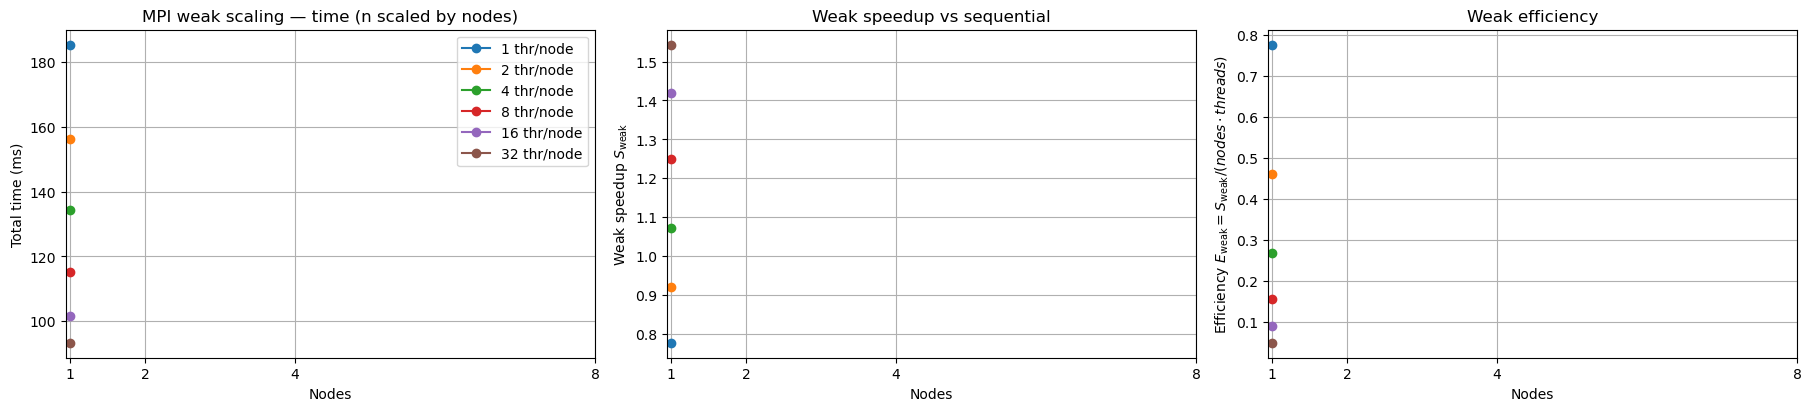

In [12]:
# --- MPI · Block 3: Weak scaling over nodes (absolute), times + speedup + efficiency ---
import math
import pandas as pd
import matplotlib.pyplot as plt

PAYLOAD_FIX = 32
P_NODES = [1, 2, 4, 8]
THREADS_PER_NODE_LIST = [1, 2, 4, 8, 16, 32]
N0 = 1_000_000
COLORS_TPN = {1:"tab:blue",2:"tab:orange",4:"tab:green",8:"tab:red",16:"tab:purple",32:"tab:brown"}

def solve_n_for_target_work(w_target):
    if w_target <= 0: return 0.0
    n = max(2.0, w_target / max(1.0, math.log2(w_target + 2.0)))
    for _ in range(50):
        f = n * math.log2(n) - w_target
        if abs(f) <= 1e-12 * max(1.0, w_target): break
        df = math.log2(n) + 1.0 / math.log(2.0)
        n -= f / df
        if n < 2.0: n = 2.0
    return n

W0 = N0 * math.log2(N0)
n_p_map = {p: int(round(solve_n_for_target_work(W0 * p))) for p in P_NODES}

# Build per (p nodes, t threads/node)
rows = []
missing = []
for tpn in THREADS_PER_NODE_LIST:
    for p in P_NODES:
        n_p = n_p_map[p]
        # sequential numerator at size n_p
        df_seq = data_raw[(data_raw["impl"]=="seq") &
                          (data_raw["threads"]==1) &
                          (data_raw["payload_max"]==PAYLOAD_FIX) &
                          (data_raw["records"]==n_p) &
                          (data_raw["sorted"]==1)]
        if df_seq.empty:
            missing.append(("seq", 1, n_p, "weak_numerator_missing"))
            continue
        T_seq = (df_seq["reading_and_sorting_ms"]).median()  # compute-only baseline

        # mpi denominator at (p nodes, tpn threads)
        df_m = mpi[(mpi["nodes"]==p) &
                   (mpi["threads"]==tpn) &
                   (mpi["payload_max"]==PAYLOAD_FIX) &
                   (mpi["records"]==n_p)]
        if df_m.empty:
            missing.append(("mpi", p, n_p, f"tpn={tpn} missing"))
            continue
        T_mpi = df_m["total_ms"].median()

        S = T_seq / T_mpi
        E = S / (p * tpn)

        rows.append({
            "tpn": tpn,
            "nodes": p,
            "records": n_p,
            "T_mpi_ms": T_mpi,
            "S_weak": S,
            "E_weak": E
        })

weak_mpi_df = pd.DataFrame(rows).sort_values(["tpn","nodes"]).reset_index(drop=True)

if missing:
    print("⚠️ Missing tuples for MPI weak scaling (impl/nodes/records/detail):")
    for t in missing:
        print("  ", t)

# Plot 3 side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)

# Times
ax = axes[0]
for tpn in THREADS_PER_NODE_LIST:
    dfl = weak_mpi_df[weak_mpi_df["tpn"]==tpn].sort_values("nodes")
    if dfl.empty: continue
    ax.plot(dfl["nodes"], dfl["T_mpi_ms"], marker="o", label=f"{tpn} thr/node", color=COLORS_TPN.get(tpn))
ax.set_xlabel("Nodes"); ax.set_ylabel("Total time (ms)")
ax.set_title("MPI weak scaling — time (n scaled by nodes)")
ax.set_xticks(P_NODES); ax.grid(True); ax.legend()

# Speedup
ax = axes[1]
for tpn in THREADS_PER_NODE_LIST:
    dfl = weak_mpi_df[weak_mpi_df["tpn"]==tpn].sort_values("nodes")
    if dfl.empty: continue
    ax.plot(dfl["nodes"], dfl["S_weak"], marker="o", label=f"{tpn} thr/node", color=COLORS_TPN.get(tpn))
ax.set_xlabel("Nodes"); ax.set_ylabel(r"Weak speedup $S_{\mathrm{weak}}$")
ax.set_title("Weak speedup vs sequential")
ax.set_xticks(P_NODES); ax.grid(True)

# Efficiency
ax = axes[2]
for tpn in THREADS_PER_NODE_LIST:
    dfl = weak_mpi_df[weak_mpi_df["tpn"]==tpn].sort_values("nodes")
    if dfl.empty: continue
    ax.plot(dfl["nodes"], dfl["E_weak"], marker="o", label=f"{tpn} thr/node", color=COLORS_TPN.get(tpn))
ax.set_xlabel("Nodes"); ax.set_ylabel(r"Efficiency $E_{\mathrm{weak}}=S_{\mathrm{weak}}/(nodes\cdot threads)$")
ax.set_title("Weak efficiency")
ax.set_xticks(P_NODES); ax.grid(True)

plt.show()


## MPI · Block 4 — Strong scaling over **nodes** (relative), plus efficiency & times

Fix $N = 100{,}000{,}000$ and `payload_max = 32`.  
For each **threads-per-node** $t$ (one line), we vary the **number of nodes** $p$ and compute:

- **Relative strong speedup (per-line $t$):**  
  $$S_{\mathrm{rel}}(p; t) = \frac{T_{\text{mpi}}(1, t, N)}{T_{\text{mpi}}(p, t, N)}$$
- **Efficiency (w.r.t nodes):**  
  $$E_{\mathrm{rel}}(p; t) = \frac{S_{\mathrm{rel}}(p; t)}{p}$$

Left subplot shows the **times** $T_{\text{mpi}}(p, t, N)$.


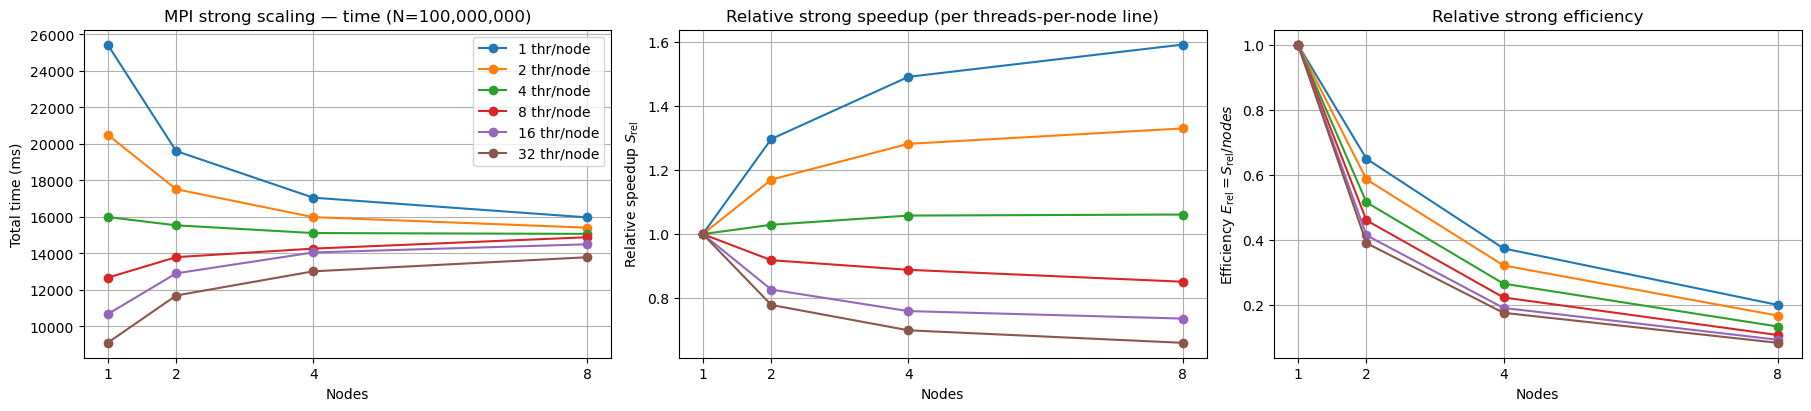

In [13]:
# --- MPI · Block 4: Strong scaling over nodes (relative), times + speedup + efficiency ---
import pandas as pd
import matplotlib.pyplot as plt

PAYLOAD_FIX = 32
N = 100_000_000
P_NODES = [1, 2, 4, 8]
THREADS_PER_NODE_LIST = [1, 2, 4, 8, 16, 32]
COLORS_TPN = {1:"tab:blue",2:"tab:orange",4:"tab:green",8:"tab:red",16:"tab:purple",32:"tab:brown"}

rows = []
missing = []

for tpn in THREADS_PER_NODE_LIST:
    # Baseline for this line: nodes=1 with same tpn
    base = mpi[(mpi["nodes"]==1) &
               (mpi["threads"]==tpn) &
               (mpi["payload_max"]==PAYLOAD_FIX) &
               (mpi["records"]==N)]
    if base.empty:
        missing.append(("mpi", 1, N, f"baseline tpn={tpn} missing"))
        continue
    T1 = base["total_ms"].median()

    for p in P_NODES:
        dfp = mpi[(mpi["nodes"]==p) &
                  (mpi["threads"]==tpn) &
                  (mpi["payload_max"]==PAYLOAD_FIX) &
                  (mpi["records"]==N)]
        if dfp.empty:
            missing.append(("mpi", p, N, f"tpn={tpn} missing"))
            continue
        Tp = dfp["total_ms"].median()
        S_rel = T1 / Tp
        E_rel = S_rel / p

        rows.append({
            "tpn": tpn,
            "nodes": p,
            "T_mpi_ms": Tp,
            "S_rel": S_rel,
            "E_rel": E_rel
        })

strong_mpi_df = pd.DataFrame(rows).sort_values(["tpn","nodes"]).reset_index(drop=True)

if missing:
    print("⚠️ Missing tuples for MPI strong (relative) (impl/nodes/records/detail):")
    for t in missing:
        print("  ", t)

# Plot 3 side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)

# Times
ax = axes[0]
for tpn in THREADS_PER_NODE_LIST:
    dfl = strong_mpi_df[strong_mpi_df["tpn"]==tpn].sort_values("nodes")
    if dfl.empty: continue
    ax.plot(dfl["nodes"], dfl["T_mpi_ms"], marker="o", label=f"{tpn} thr/node", color=COLORS_TPN.get(tpn))
ax.set_xlabel("Nodes"); ax.set_ylabel("Total time (ms)")
ax.set_title(f"MPI strong scaling — time (N={N:,})")
ax.set_xticks(P_NODES); ax.grid(True); ax.legend()

# Relative speedup
ax = axes[1]
for tpn in THREADS_PER_NODE_LIST:
    dfl = strong_mpi_df[strong_mpi_df["tpn"]==tpn].sort_values("nodes")
    if dfl.empty: continue
    ax.plot(dfl["nodes"], dfl["S_rel"], marker="o", label=f"{tpn} thr/node", color=COLORS_TPN.get(tpn))
ax.set_xlabel("Nodes"); ax.set_ylabel(r"Relative speedup $S_{\mathrm{rel}}$")
ax.set_title("Relative strong speedup (per threads-per-node line)")
ax.set_xticks(P_NODES); ax.grid(True)

# Efficiency (per nodes)
ax = axes[2]
for tpn in THREADS_PER_NODE_LIST:
    dfl = strong_mpi_df[strong_mpi_df["tpn"]==tpn].sort_values("nodes")
    if dfl.empty: continue
    ax.plot(dfl["nodes"], dfl["E_rel"], marker="o", label=f"{tpn} thr/node", color=COLORS_TPN.get(tpn))
ax.set_xlabel("Nodes"); ax.set_ylabel(r"Efficiency $E_{\mathrm{rel}}=S_{\mathrm{rel}}/nodes$")
ax.set_title("Relative strong efficiency")
ax.set_xticks(P_NODES); ax.grid(True)

plt.show()
